In [1]:
# Import NumPy for numerical operations, arrays, and mathematical functions
import numpy as np

# Import Matplotlib's pyplot module for creating plots, graphs, and visualizations
import matplotlib.pyplot as plt

# Import Pandas for handling tabular data (DataFrames), reading CSV/Excel files, and data manipulation
import pandas as pd

In [3]:
# Load the dataset from a CSV file into a Pandas DataFrame
dataset = pd.read_csv('Position_Salaries_100_Realistic.csv')

# Extract the independent variable(s) (Position Level column)
# iloc[:, 1:-1] → selects all rows, from column index 1 up to but not including the last column
# .values → converts the DataFrame slice into a NumPy array
X = dataset.iloc[:, 1:-1].values

# Extract the dependent variable (Salary column)
# iloc[:, -1] → selects all rows, only the last column
# .values → converts it into a NumPy array
y = dataset.iloc[:, -1].values


### Decision Tree Regression Model

- We import `DecisionTreeRegressor` from scikit‑learn.  
- Initialize the regressor with a fixed `random_state` for reproducibility.  
- Fit the regressor on our dataset (`X` as features, `y` as target).  
- This model will learn decision rules from the data to predict salaries based on position levels.

In [4]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor with a fixed random state
regressor = DecisionTreeRegressor(random_state=0)

# Fit the model to the dataset (training step)
regressor.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

### Making a Prediction with Decision Tree Regressor

- After fitting the model, we can use `predict()` to estimate the salary for a given position level.  
- Here, we pass `[[6.5]]` as input (position level = 6.5).  
- The model will return the predicted salary based on the decision rules it learned from the dataset.

In [5]:
# Predict the salary for position level 6.5
regressor.predict([[6.5]])

array([105218.22222222])

### Visualising the Decision Tree Regression Results (Higher Resolution)

- To get a smoother curve, we create a dense grid of `X` values using `np.arange` with a small step (0.01).  
- Reshape the grid into a column vector so it matches the expected input format.  
- Plot the actual data points (red scatter).  
- Plot the predicted curve from the Decision Tree model (blue line).  
- Add title, labels, and show the plot.

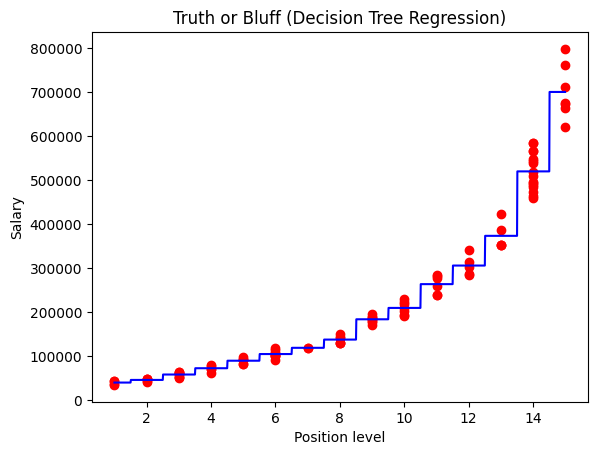

In [7]:
# Create a dense grid of X values for higher resolution visualization
X_grid = np.arange(min(X[:, 0]), max(X[:, 0]), 0.01)  # use the first column
X_grid = X_grid.reshape((len(X_grid), 1))

# Plot actual data points
plt.scatter(X, y, color='red')

# Plot predictions from the Decision Tree model
plt.plot(X_grid, regressor.predict(X_grid), color='blue')

# Add title and axis labels
plt.title('Truth or Bluff (Decision Tree Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')

# Display the plot
plt.show()

# 🌳 Decision Tree Regression : Interpretation

---

#### 🔴 Actual Data (Red Dots)
- Each red dot represents the **true salary** for a given position level.  
- This is the ground truth we want our model to learn.

---

#### 🔵 Predicted Curve (Blue Line)
- The blue line shows the **Decision Tree’s predictions**.  
- Notice the **step-like pattern**:  
  - Decision Trees split the input space into intervals.  
  - Within each interval, the prediction is constant (average of points in that region).  
  - That’s why the line is flat in chunks, then jumps suddenly.

---

#### Key Insight
- Decision Tree Regression is **non-parametric**, it doesn’t assume linear or polynomial trends.  
- Instead, it builds **rules**:  
  - *“If position < 5 → predict X”*  
  - *“If position between 5 and 7 → predict Y”*  
- The result is a **staircase approximation** of the data.

---

#### Takeaway
- **Strength:** Very flexible, can capture complex patterns.  
- **Limitation:** Predictions are not smooth, they look like steps.  
- This step-like behavior is the **signature of Decision Tree Regression**.


# Decision Tree Regression : Understanding How It Works

---

## 1. The Dataset
We have a table of **Position Level** (numeric feature) and **Salary** (numeric target).  
Each row represents a role (Intern, Engineer, Director, COO, CEO, etc.) with its level and corresponding salary.  
This is the input (`X`) and output (`y`) for our regression model.

---

## 2. Model Setup
The `DecisionTreeRegressor` builds a **tree of rules**.  
- It starts at the root and asks: *“Should I split the data here?”*  
- Splits are chosen to minimize error (criterion = `squared_error`).  
- Parameters like `max_depth=None` allow the tree to grow until no further improvement is possible.  
- `random_state=0` ensures the same splits every time for reproducibility.

---

## 3. Training Process
When we call `fit(X, y)`, the model:
- Recursively partitions the feature space (Position Level).  
- In each partition, it stores the **average salary** of the samples inside.  
- This creates a **piecewise constant function**, flat predictions within intervals, jumps at split boundaries.

---

## 4. Making Predictions
When we call `predict([[6.5]])`, the model:
- Finds which interval the value `6.5` belongs to.  
- Returns the average salary of all training samples in that interval.  
- This is why predictions are **step-like** rather than smooth.

---

## 5. Visual Signature
The graph shows:
- **Red dots** → actual salaries from the dataset.  
- **Blue line** → model predictions.  
- The line is flat in chunks (constant prediction per interval) and jumps suddenly at split points.  
This staircase pattern is the hallmark of Decision Tree Regression.

---

## 6. Point Takeaway
- **Strengths:** Captures complex, non-linear patterns without assuming a specific formula.  
- **Limitations:** Predictions are not continuous; they look like steps.  
- Think of it as a **flowchart of rules**:  
  - *If Level < 5 → predict average salary of those roles.*  
  - *If Level between 5 and 10 → predict another average.*  
  - And so on.  

Decision Tree Regression is best understood as a **rule-based partitioning of the input space**, producing a staircase approximation of the target values.

# Comparative Understanding: Linear Regression vs SVR vs Decision Tree Regression

| Aspect | Linear Regression | Support Vector Regression (SVR) | Decision Tree Regression |
|--------|-------------------|---------------------------------|--------------------------|
| **Core Idea** | Fits a straight line (or hyperplane) that minimizes squared error. | Fits a function within an ε-tube, penalizing points outside it. Can use kernels (linear, polynomial, RBF). | Splits the feature space into intervals using rules, predicts average in each region. |
| **Assumptions** | Assumes linear relationship between features and target. | Does not assume linearity; depends on chosen kernel. | No assumptions about data distribution or linearity. |
| **Model Output Shape** | Always a straight line (or plane in higher dimensions). | Flexible: can be linear (with linear kernel) or non-linear (with RBF kernel). Produces smooth curves. | Step-like function (piecewise constant). Predictions jump at split boundaries. |
| **Interpretability** | Highly interpretable: coefficients show feature impact. | Less interpretable: kernel transformations are abstract. | Easy to interpret: resembles a flowchart of rules. |
| **Strengths** | Simple, fast, interpretable. Works well when data truly follows a linear trend. | Very flexible, handles both linear and non-linear data. Good at controlling margin and robustness. | Captures complex patterns, non-parametric, handles categorical and continuous features. |
| **Limitations** | Poor fit if data is non-linear. Sensitive to outliers. | Sensitive to choice of kernel and hyperparameters (C, ε, γ). Computationally heavier. | Predictions are not smooth (staircase effect). Can overfit if tree grows too deep. |
| **Works Best When** | Data shows a clear linear trend and interpretability is important. | Data may be linear or non-linear, especially when smooth approximation is desired. | Data has complex, irregular patterns or rule-like splits. |
| **Why It Works Well There** | Because linear regression directly models proportional relationships. | Because SVR adapts via kernels, balancing flatness and slack penalties. | Because decision trees partition space into meaningful regions, capturing heterogeneity. |

# Interview Question: Is Feature Scaling Important in Decision Trees?

---

### Question
**Is feature scaling (normalization or standardization) important when training a Decision Tree model?**

---

### Answer
No, feature scaling is **not important** for Decision Trees.  
Here’s why:

- **Decision Trees split based on thresholds** of feature values (e.g., *“Is Level < 5?”*).  
- These splits depend only on the **relative ordering** of values, not their magnitude.  
- Whether the feature is measured in meters, kilometers, or normalized between 0 and 1, the ordering remains the same, so the splits are identical.  

---

## Deep Explanation
- In models like **Linear Regression** or **Support Vector Regression**, scaling matters because:
  - Coefficients are sensitive to feature magnitude.
  - Distance-based calculations (like margins in SVR) depend on scale.
- In **Decision Trees**, the algorithm only asks: *“Which feature and threshold best reduce impurity?”*  
  - It does not compute distances.
  - It does not rely on gradient descent.
  - It only compares values to find splits.

---

#### Takeaway
- **Decision Trees:** Scaling not required.  
- **Linear/Distance-based models:** Scaling is crucial.  
- This makes Decision Trees very convenient when working with raw, unscaled data.

---

### Summary
Feature scaling does **not affect Decision Tree performance** because the model is based on **ordering and thresholding** rather than magnitude or distance.  
This is one of the reasons Decision Trees are considered **robust and easy to use** in practice.


# Frequently Asked Decision Tree Interview Questions

---

## 1. What is the intuition behind Decision Trees?
**Answer:**  
Decision Trees work by recursively splitting the dataset into smaller subsets based on feature values. At each node, the algorithm chooses the feature and threshold that best separates the data according to a criterion (like Gini impurity or variance reduction).

**Deep Explanation:**  
- The tree starts at the root and asks a simple question: *“Is feature X < threshold?”*  
- Based on the answer, the data is split into branches.  
- This process continues until a stopping condition is reached (e.g., maximum depth, minimum samples per leaf).  
- The final nodes (leaves) contain predictions,  either a class label (classification) or an average value (regression).  
This makes Decision Trees easy to interpret, as they resemble a flowchart of rules.

---

## 2. Why don’t Decision Trees require feature scaling?
**Answer:**  
Decision Trees are based on thresholding and ordering of values, not on distances or magnitudes. Therefore, scaling features (normalization or standardization) does not affect the splits.

**Deep Explanation:**  
- Models like Linear Regression or Support Vector Machines rely on distance calculations or gradient descent, which are sensitive to feature magnitude.  
- Decision Trees only compare values: *“Is feature ≤ threshold?”*  
- Whether the feature is in meters, kilometers, or normalized between 0 and 1, the ordering remains the same.  
This robustness makes Decision Trees convenient for raw, unscaled data.

---

## 3. What are the main limitations of Decision Trees?
**Answer:**  
Decision Trees can easily overfit the training data, producing complex trees that do not generalize well. They also produce step-like predictions in regression tasks, which may not capture smooth trends.

**Deep Explanation:**  
- **Overfitting:** If the tree grows too deep, it memorizes training data instead of learning general patterns.  
- **Instability:** Small changes in data can lead to very different splits, making trees sensitive to noise.  
- **Step-like predictions:** In regression, trees output constant values within intervals, leading to non-smooth approximations.  
To overcome these issues, ensemble methods like Random Forests or Gradient Boosted Trees are often used, combining many trees to improve stability and accuracy.

---

## Note Takeaway
- Decision Trees are intuitive and interpretable, but prone to overfitting.  
- They don’t require feature scaling, which makes preprocessing simpler.  
- Their limitations are often addressed by ensemble methods, which build on the same foundation but add robustness.
